In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


```This dataset has 150 samples with 4 numerical features. Since we are using K-Means, we will not use the target column.```

In [3]:
# Standardize the dataset
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert to DataFrame for visualization
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

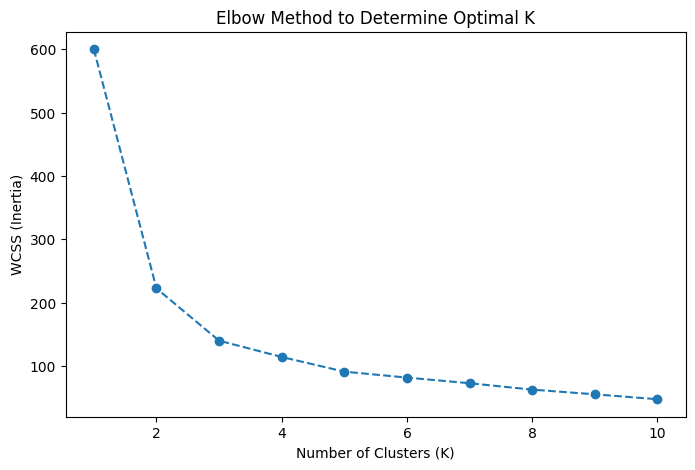

In [4]:
# Compute WCSS for different values of K
wcss = []
K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  # WCSS (Sum of squared distances)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_values, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method to Determine Optimal K')
plt.show()


```Apply K-Means clustring```

In [5]:
from sklearn.cluster import KMeans

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# View first five rows with assigned cluster labels
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


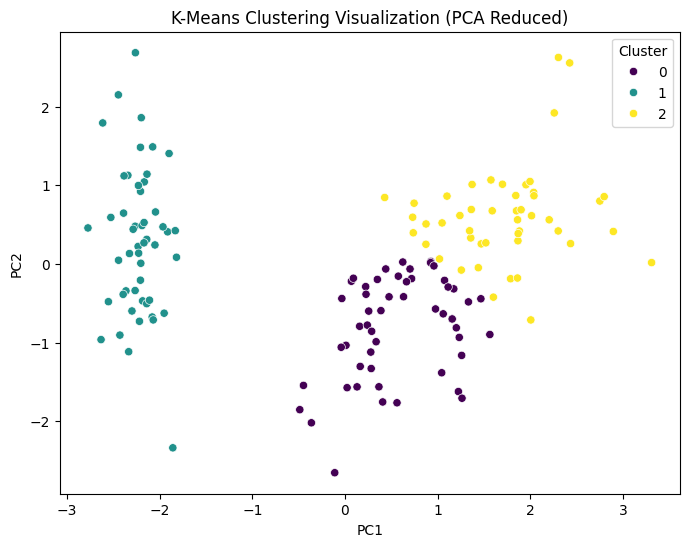

In [6]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Convert to DataFrame
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# Scatter plot of clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue=df_pca['Cluster'], palette='viridis', data=df_pca)
plt.title('K-Means Clustering Visualization (PCA Reduced)')
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

# Compute silhouette score
score = silhouette_score(df_scaled, df['Cluster'])
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.460


Closer to 1 → Clusters are well-separated

Around 0 → Overlapping clusters

Closer to -1 → Misclassified points

```analyzing the cluster characteristics ```

In [8]:
# Compute mean feature values for each cluster
cluster_means = df.groupby('Cluster').mean()
print(cluster_means)

         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                 5.801887          2.673585           4.369811   
1                 5.006000          3.428000           1.462000   
2                 6.780851          3.095745           5.510638   

         petal width (cm)  
Cluster                    
0                1.413208  
1                0.246000  
2                1.972340  


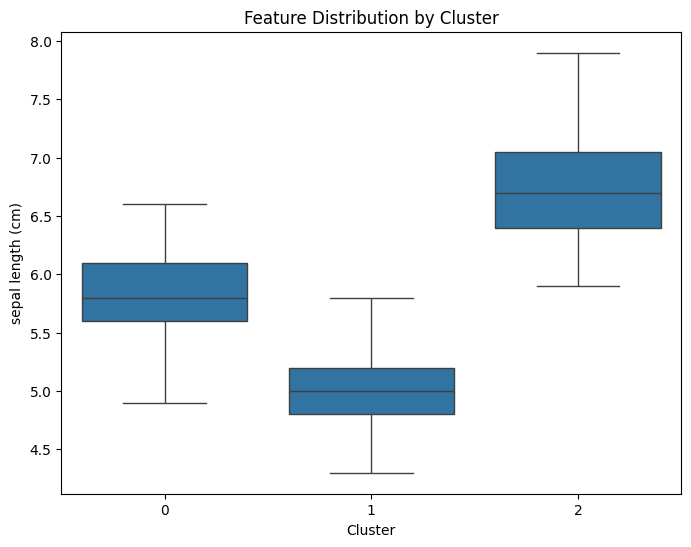

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Replace 'Feature_Name' with an actual feature from your DataFrame
feature_of_interest = 'sepal length (cm)'  # Example: Choose a feature

# Visualizing distributions for an important feature
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y=feature_of_interest, data=df)  # Change here
plt.title('Feature Distribution by Cluster')
plt.show()

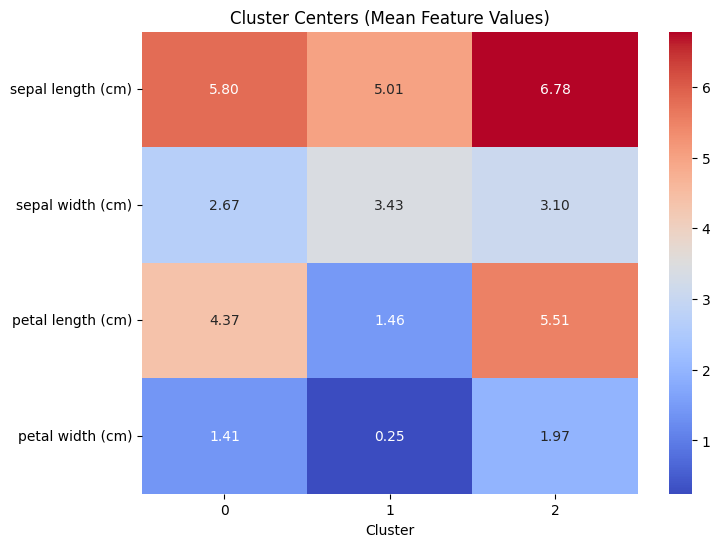

In [11]:
# Plot the cluster centers
plt.figure(figsize=(8, 6))
sns.heatmap(cluster_means.T, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Cluster Centers (Mean Feature Values)")
plt.show()

# **Cluster Analysis of K-Means (Iris Dataset)**

This heatmap represents the **cluster centers** of the K-Means algorithm applied to the **Iris dataset**. Each value in the heatmap shows the **mean feature value** for a particular cluster.

---

## **1. Understanding the Axes**
- **X-axis (Cluster 0, 1, 2)** → Represents the three clusters created by K-Means.
- **Y-axis (Features: Sepal Length, Sepal Width, Petal Length, Petal Width)** → Represents the four features in the dataset.

Each cell contains the **mean value of the feature** for that cluster.

---

## **2. Cluster Interpretation**

### **Cluster 0:**
- **Sepal Length**: 5.80 (moderate)
- **Sepal Width**: 2.67 (narrow)
- **Petal Length**: 4.37 (moderate)
- **Petal Width**: 1.41 (moderate)
- **Interpretation**: Likely represents **Versicolor** (medium-sized petals and sepals).

### **Cluster 1:**
- **Sepal Length**: 5.01 (shortest)
- **Sepal Width**: 3.43 (widest)
- **Petal Length**: 1.46 (smallest)
- **Petal Width**: 0.25 (smallest)
- **Interpretation**: Likely represents **Setosa**, which has **small petals and large sepals**.

### **Cluster 2:**
- **Sepal Length**: 6.78 (largest)
- **Sepal Width**: 3.10 (moderate)
- **Petal Length**: 5.51 (largest)
- **Petal Width**: 1.97 (largest)
- **Interpretation**: Likely represents **Virginica**, which has **long sepals and petals**.

---

## **3. Key Insights from the Heatmap**
1. **Sepal Length:**
   - Cluster 2 has the **longest sepals** (Virginica).
   - Cluster 1 has the **shortest sepals** (Setosa).

2. **Sepal Width:**
   - Cluster 1 has the **widest sepals**.
   - Cluster 0 has the **narrowest sepals**.

3. **Petal Length and Petal Width:**
   - **Cluster 1 has the smallest petals** → Clearly **Setosa**.
   - **Cluster 2 has the longest petals** → Likely **Virginica**.

---

## **4. Practical Applications**
- **Label Prediction**: If a new flower comes in with **petal length ≈ 5.5**, it's likely **Cluster 2 (Virginica)**.
- **Feature Importance**: **Petal length & width** are the **most important** in differentiating clusters.
- **Business Example**: If this were a customer segmentation dataset, clusters could represent **low, medium, and high-value customers**.

Would you like to verify these clusters against actual species labels?
